In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [25]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/transactions_clean.csv")
scheme = pd.read_csv("../data/processed/scheme_clean.csv")

In [26]:
import os
print("curreent working Directory:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

curreent working Directory:
c:\Users\KOWSHIK\OneDrive\Documents\Python Programes\Mutual-Fund-Analytics\notebooks

Files in current folder:
['EDA_Analysis.ipynb', 'eda_analysis.py']


In [27]:
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/transactions_clean.csv")
scheme = pd.read_csv("../data/processed/scheme_clean.csv")

print(fund_master.head())
print(nav_history.head())
print(transactions.head())
print(scheme.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

### 1 ST CHART

# Chart 1: Daily NAV Trend Analysis (2022–2026)

Objective:
This chart shows the daily NAV trend of mutual fund schemes from 2022 to 2026.

In [ ]:
import plotly.express as px

nav_history['date'] = pd.to_datetime(nav_history['date'])

fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022-2026)'
)
fig.write_image("../reports/chart_01.png", scale=3)

fig.show()

## Finding 1

Insight:
Daily NAV values showed an overall upward trend from 2022 to 2026.

Reference:
Chart 1 – Daily NAV Trend Analysis (2022–2026)

#### 2ND CHART

# Chart 2: AUM Growth by Fund House (2022–2025)

**Objective:**
This chart compares the Assets Under Management (AUM) of different fund houses from 2022 to 2025. It helps identify the leading fund houses and their growth over the analysis period.

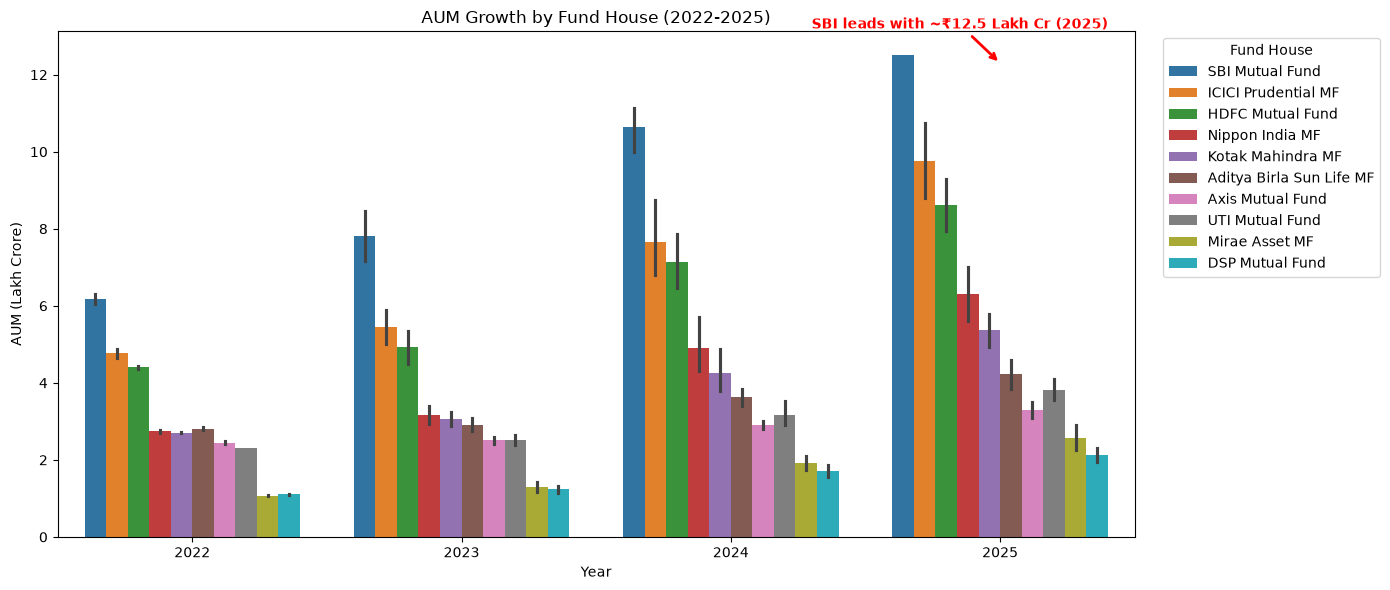

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create Year column
aum["year"] = aum["date"].dt.year

# Plot grouped bar chart
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()



plt.annotate(
    "SBI leads with ~₹12.5 Lakh Cr (2025)",
    xy=(3, 12.3),
    xytext=(2.3, 13.2),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
    color="red",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../reports/chart_02.png", dpi=300, bbox_inches="tight")
plt.show()


## Finding 2

**Insight:**
SBI Mutual Fund maintained the highest AUM among all fund houses throughout the analysis period, while other leading fund houses also showed steady growth.

**Reference:**
Chart 2 – AUM Growth by Fund House (2022–2025)

### 3RD CHART

# Chart 3: Monthly SIP Inflow Trend

**Objective:**
This chart shows the monthly SIP (Systematic Investment Plan) inflow trend over the analysis period. It helps identify growth in SIP investments and monthly investment patterns.

In [ ]:
import pandas as pd
import plotly.express as px

# Convert transaction_date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Keep only SIP transactions
sip = transactions[transactions["transaction_type"] == "SIP"].copy()

# Create Year-Month column
sip["month"] = sip["transaction_date"].dt.to_period("M").astype(str)

# Monthly SIP inflow
monthly_sip = sip.groupby("month")["amount_inr"].sum().reset_index()

# Plot
fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Amount (₹)"
)
fig.write_image("../reports/chart_03.png", scale=3)
fig.show()

## Finding 3

**Insight:**
Monthly SIP inflows showed a steady increasing trend over time, indicating growing investor participation through systematic investments.

**Reference:**
Chart 3 – Monthly SIP Inflow Trend

### 4TH CHART

# Chart 4: Category Inflow Heatmap

**Objective:**
This heatmap visualizes monthly investment inflows across different mutual fund categories. It helps identify which fund categories received the highest investor inflows over time.

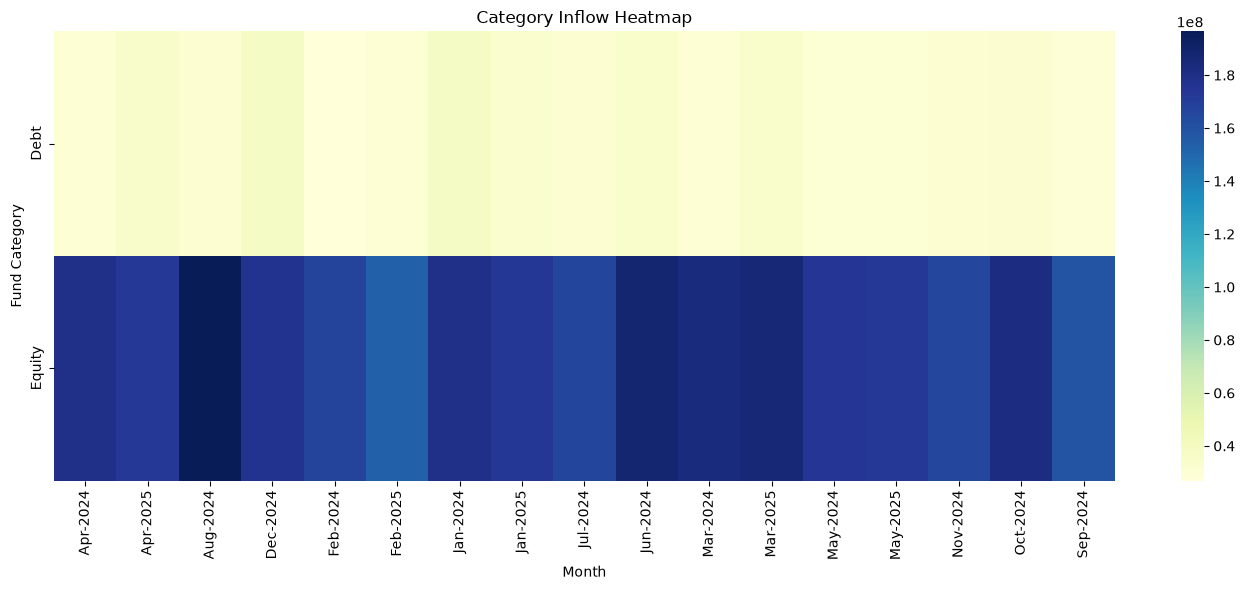

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert transaction date to datetime
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# Create Month column
transactions['Month'] = transactions['transaction_date'].dt.strftime('%b-%Y')

# Merge transactions with fund master to get category
heatmap_data = transactions.merge(
    fund_master[['amfi_code', 'category']],
    on='amfi_code',
    how='left'
)

# Group by Month and Category
heatmap_data = heatmap_data.groupby(
    ['category', 'Month']
)['amount_inr'].sum().unstack(fill_value=0)

# Plot Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig("../reports/chart_04.png", dpi=300, bbox_inches="tight")
plt.show()


## Finding 4

**Insight:**
Equity funds consistently attracted higher investment inflows than most other fund categories, indicating strong investor preference.

**Reference:**
Chart 4 – Category Inflow Heatmap

#### 5TH (A)CHART

# Chart 5: Investor Demographics Analysis

**Objective:**
This section analyzes investor demographics, including age group distribution, SIP investment amount by age group, and gender distribution of investors.

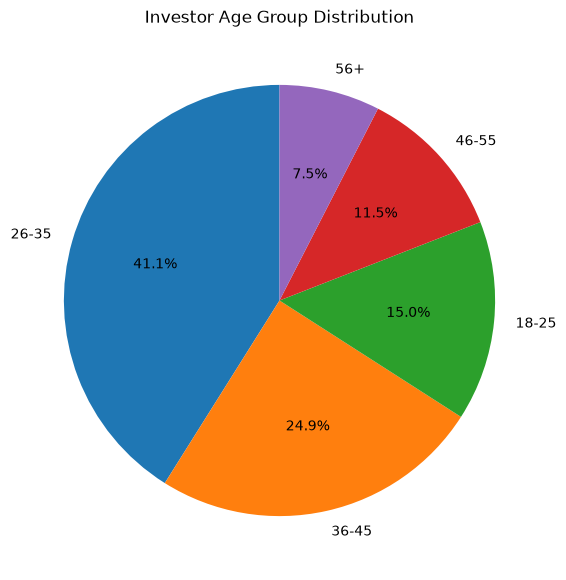

In [ ]:
import matplotlib.pyplot as plt

age_counts = transactions['age_group'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.savefig("../reports/chart_05A.png", dpi=300, bbox_inches="tight")
plt.show()

### 5TH (B)CHART

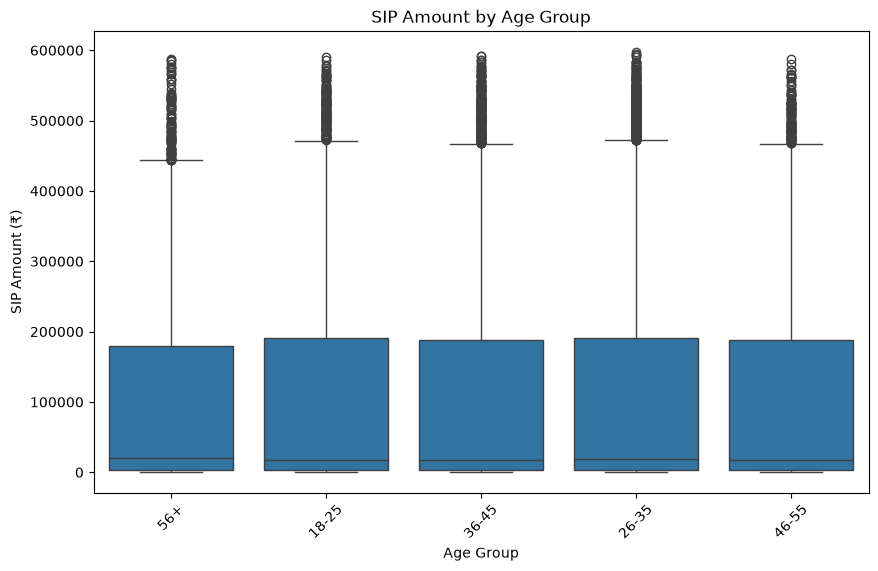

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.xticks(rotation=45)
plt.savefig("../reports/chart_05B.png", dpi=300, bbox_inches="tight")
plt.show()

### 5TH (C) CHART

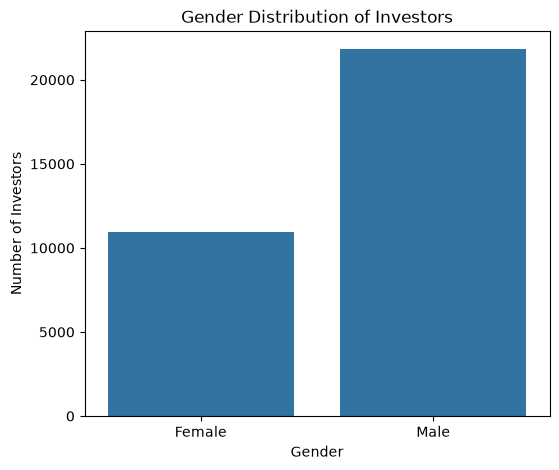

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")
plt.savefig("../reports/chart_05C.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 5

**Insight:**
The 26–35 age group represents the largest share of investors. SIP investment amounts vary across age groups, while male investors slightly outnumber female investors in the dataset.

**Reference:**
Chart 5A – Investor Age Group Distribution

Chart 5B – SIP Amount by Age Group

Chart 5C – Gender Distribution of Investors

### 6TH CHART

# Chart 6: Geographical Distribution Analysis

**Objective:**
This chart analyzes the geographical distribution of SIP investments across different states and city tiers to identify regions with higher investor participation.

C:\Users\KOWSHIK\AppData\Local\Temp\ipykernel_17660\2576240597.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


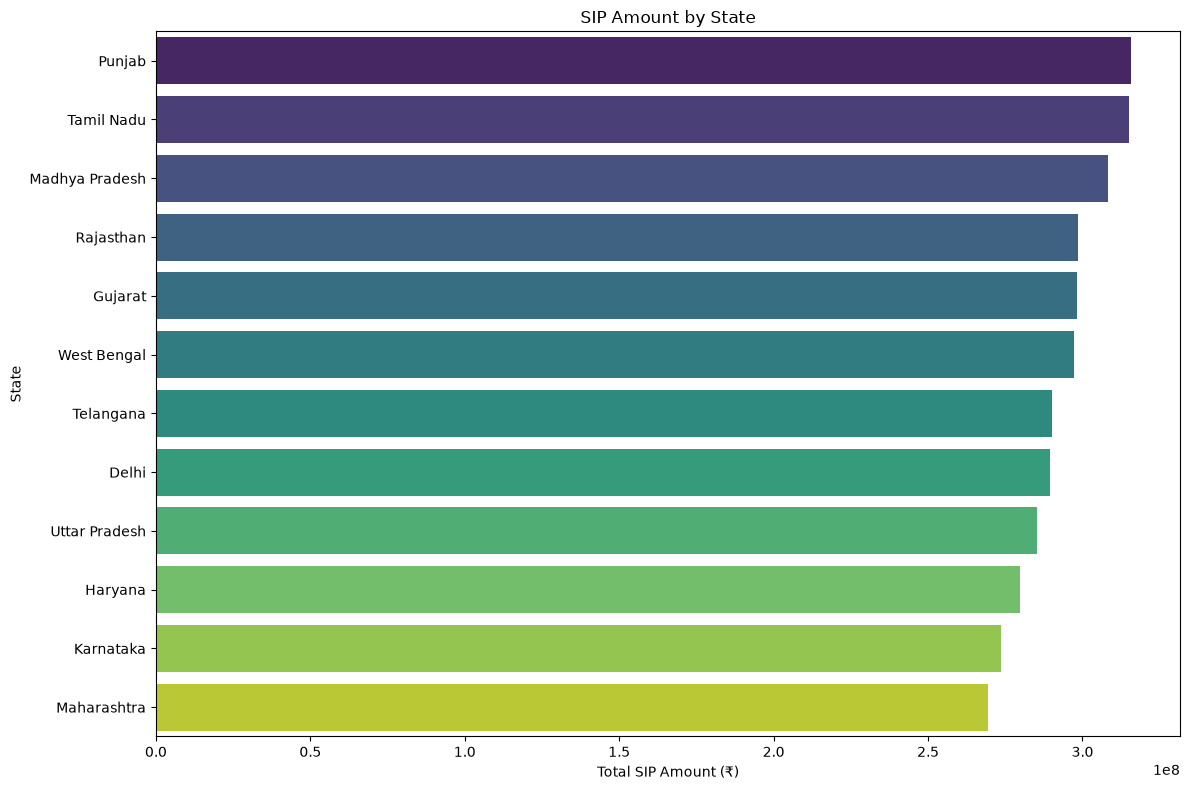

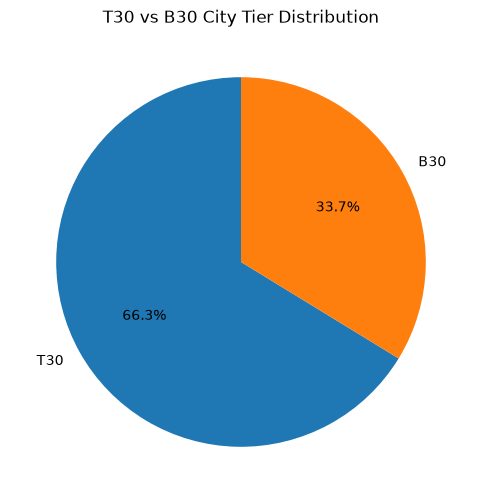

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Horizontal Bar Chart - SIP Amount by State
# -------------------------------

state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(
    x=state_data.values,
    y=state_data.index,
    palette="viridis"
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# -------------------------------
# Pie Chart - City Tier
# -------------------------------

city_data = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    city_data,
    labels=city_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
fig.write_image("../reports/chart_06.png", scale=3)
fig.show()


## Finding 6

**Insight:**
Major metropolitan states and Tier-1 cities contributed the highest SIP investment amounts, indicating stronger investor participation in urban regions.

**Reference:**
Chart 6 – Geographical Distribution Analysis

### 7TH CHART

# Chart 7: Folio Count Growth Analysis

**Objective:**
This chart shows the monthly growth in investor folio count from 2022 to 2025, helping identify trends in investor participation over time.

In [ ]:
import pandas as pd
import plotly.express as px

# Monthly folio count
folio = (
    transactions
    .groupby(pd.to_datetime(transactions["transaction_date"]).dt.to_period("M"))["investor_id"]
    .nunique()
    .reset_index()
)

folio.columns = ["month", "folio_count"]
folio["month"] = folio["month"].astype(str)

fig = px.line(
    folio,
    x="month",
    y="folio_count",
    markers=True,
    title="Folio Count Growth (Jan 2022 - Dec 2025)"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Folios"
)
fig.write_image("../reports/chart_07.png", scale=3)
fig.show()


## Finding 7

**Insight:**
The total number of investor folios increased steadily over the analysis period, indicating continuous growth in mutual fund participation.

**Reference:**
Chart 7 – Folio Count Growth Analysis

#### 8TH CHART

# Chart 8: Correlation Analysis of Fund Returns

**Objective:**
This chart analyzes the correlation between the daily NAV returns of the top mutual funds to identify funds with similar performance patterns and diversification opportunities.

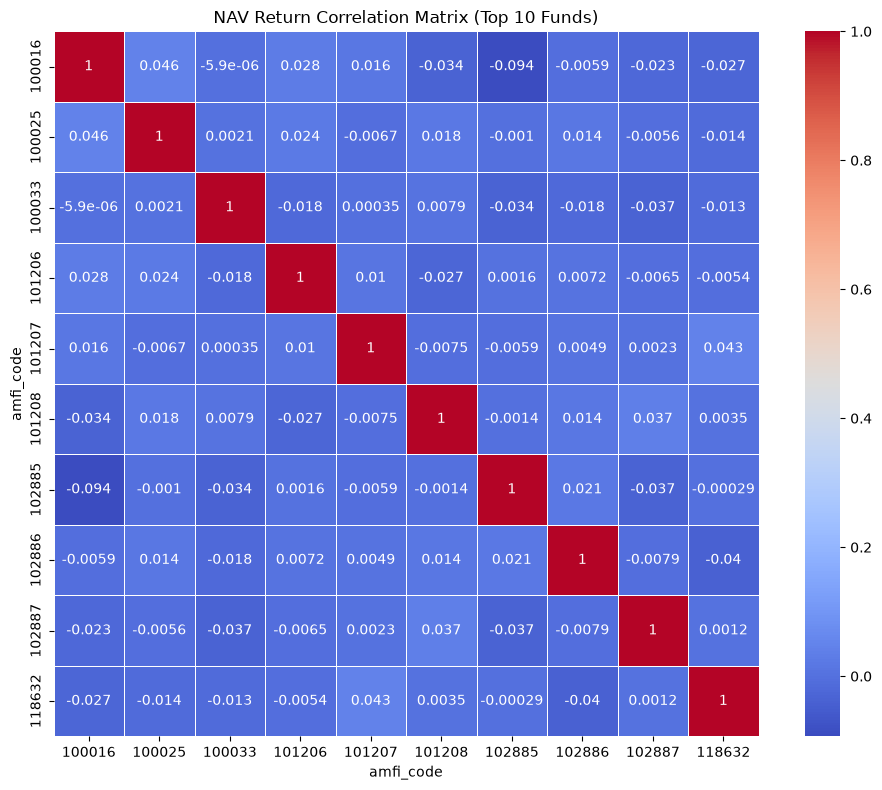

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select 10 funds
top10 = nav_history["amfi_code"].unique()[:10]

# Filter data
chart8 = nav_history[nav_history["amfi_code"].isin(top10)].copy()

# Convert date
chart8["date"] = pd.to_datetime(chart8["date"])

# Create pivot table
pivot = chart8.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
daily_returns = pivot.pct_change().dropna()

# Correlation matrix
corr = daily_returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")
plt.tight_layout()
plt.savefig("../reports/chart_08.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 8

**Insight:**
The correlation heatmap shows that some mutual funds have strong positive correlations, indicating similar market movements, while others have weaker correlations, providing better portfolio diversification.

**Reference:**
Chart 8 – Correlation Analysis of Fund Returns

### 09 chart

# Chart 9: Top 10 Fund Houses by Number of Schemes

**Objective:**
This chart compares the top 10 mutual fund houses based on the total number of schemes they offer, highlighting the most diversified fund providers in the dataset.

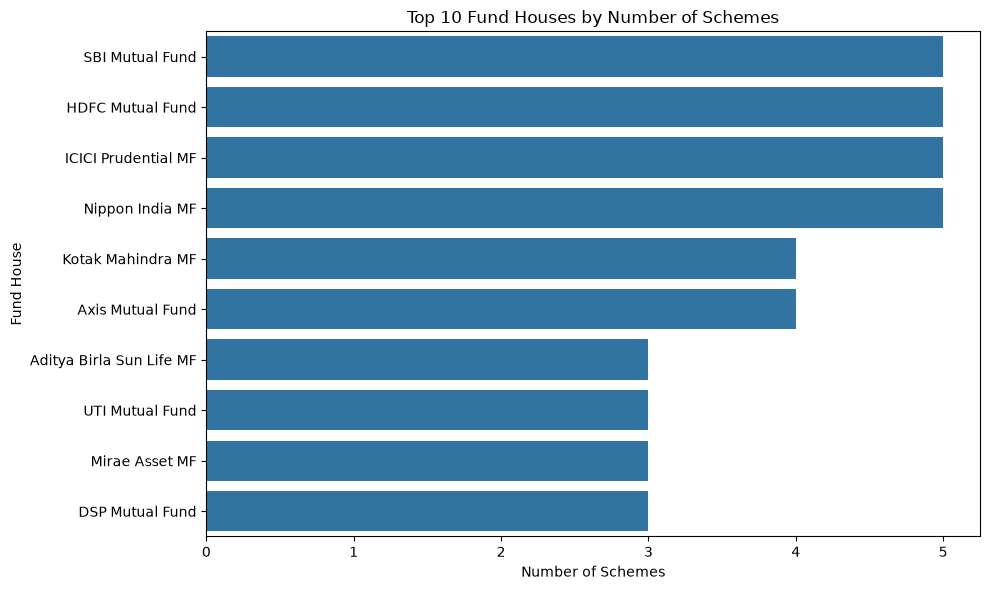

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

plt.figure(figsize=(10,6))

top_fund_house = fund_master["fund_house"].value_counts().head(10)

sns.barplot(
    x=top_fund_house.values,
    y=top_fund_house.index
)

plt.title("Top 10 Fund Houses by Number of Schemes")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

plt.tight_layout()
plt.savefig("../reports/chart_09.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 9

**Insight:**
SBI Mutual Fund offers the highest number of schemes, followed by HDFC Mutual Fund and ICICI Prudential Mutual Fund, indicating their strong presence and wide product portfolio.

**Reference:**
Chart 9 – Top 10 Fund Houses by Number of Schemes

### 10TH CHART

# Chart 10: Distribution of Mutual Fund Schemes by Risk Category

**Objective:**
This chart shows the distribution of mutual fund schemes across different risk categories, helping investors understand the availability of low, moderate, high, and very high risk investment options.

C:\Users\KOWSHIK\AppData\Local\Temp\ipykernel_17660\2660369792.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


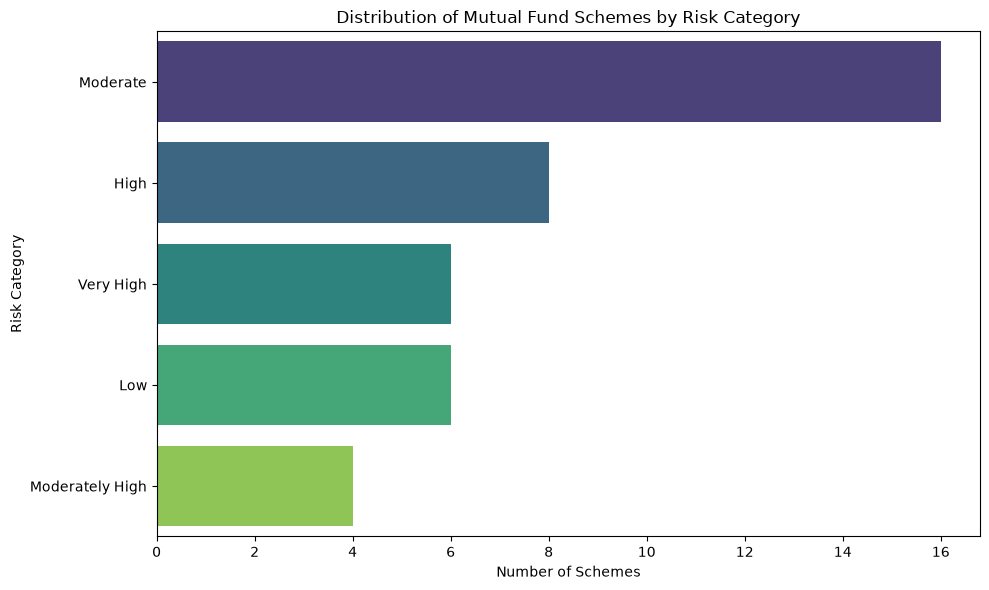

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Plot
plt.figure(figsize=(10,6))

sns.countplot(
    data=fund_master,
    y="risk_category",
    order=fund_master["risk_category"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Mutual Fund Schemes by Risk Category")
plt.xlabel("Number of Schemes")
plt.ylabel("Risk Category")

plt.tight_layout()
plt.savefig("../reports/chart_10.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 10

**Insight:**
Most mutual fund schemes belong to Moderate and High risk categories, while fewer schemes are available in the Low risk category. This indicates that the market offers a greater number of growth-oriented investment options.

**Reference:**
Chart 10 – Distribution of Mutual Fund Schemes by Risk Category

### 11TH CHART

# Chart 11: Distribution of Mutual Fund Risk Categories

**Objective:**
To visualize the proportion of mutual fund schemes across different risk categories using a pie chart.

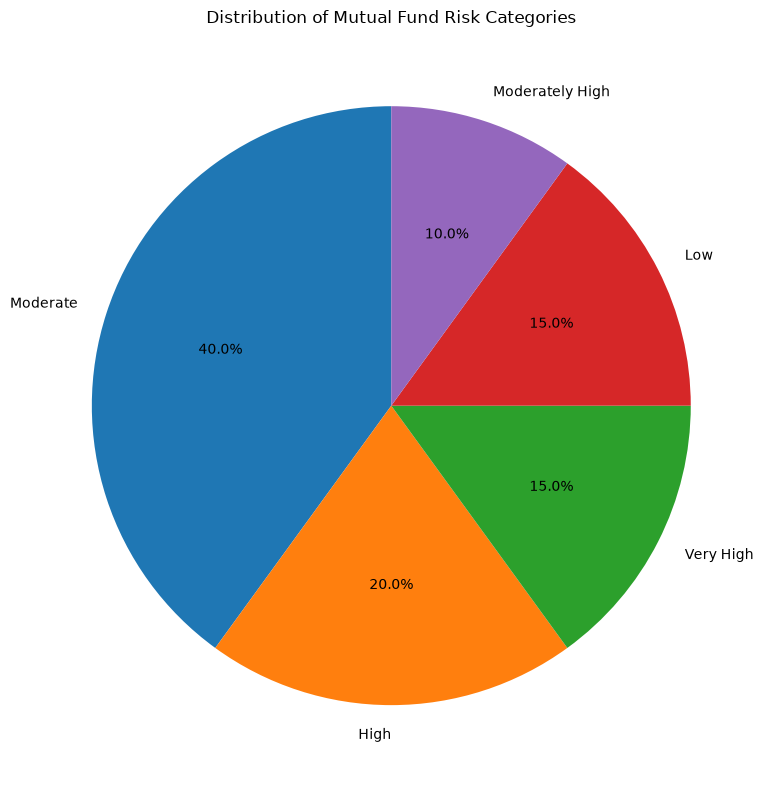

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Count risk categories
risk = fund_master["risk_category"].value_counts()

# Plot
plt.figure(figsize=(8,8))

plt.pie(
    risk,
    labels=risk.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Mutual Fund Risk Categories")

plt.tight_layout()
plt.savefig("../reports/chart_11.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 11

**Insight:**
Most mutual fund schemes belong to Moderate to High and High risk categories, while fewer schemes are available in the Low risk category.

**Reference:**
Chart 11 – Distribution of Mutual Fund Risk Categories.

#### 12TH CHART

# Chart 12: 1-Year Returns Distribution

**Objective:**
To analyze the distribution of one-year returns of mutual fund schemes using a histogram.

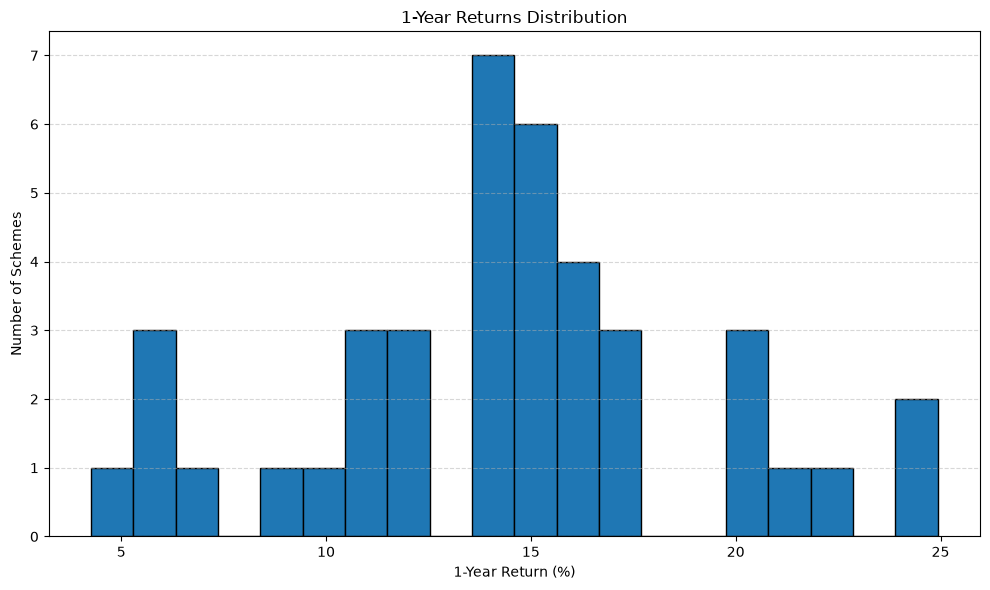

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

plt.figure(figsize=(10,6))
plt.hist(performance["return_1yr_pct"], bins=20, edgecolor="black")

plt.title("1-Year Returns Distribution")
plt.xlabel("1-Year Return (%)")
plt.ylabel("Number of Schemes")

plt.grid(axis='y',alpha=0.5,linestyle='--')

plt.tight_layout()
plt.savefig("../reports/chart_12.png", dpi=300, bbox_inches="tight")
plt.show()


## Finding 12

**Insight:**
Most mutual fund schemes generated moderate one-year returns, while only a few schemes recorded exceptionally high or low returns.

**Reference:**
Chart 12 – 1-Year Returns Distribution.

### 13th chart

# Chart 13: Investor Transaction Type Distribution

**Objective:**
To visualize the proportion of different investor transaction types using a pie chart.

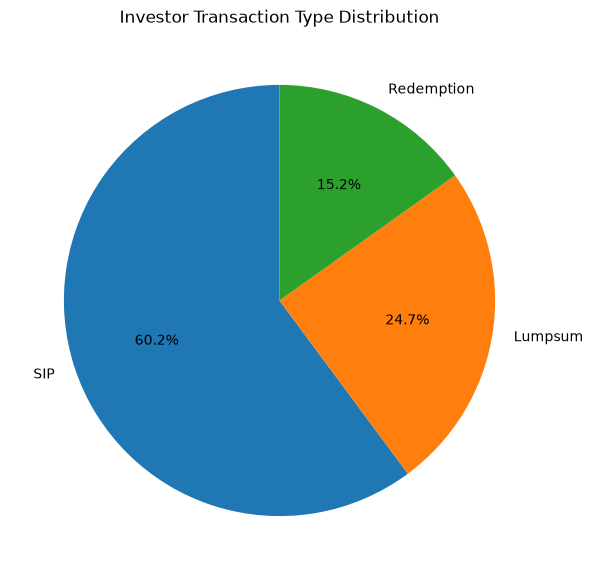

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/08_investor_transactions.csv")

counts = df["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Transaction Type Distribution")
plt.savefig("../reports/chart_13.png", dpi=300, bbox_inches="tight")
plt.show()


## Finding 13

**Insight:**
Purchase transactions account for the largest share of investor activity, followed by redemption and SIP transactions.

**Reference:**
Chart 13 – Investor Transaction Type Distribution.

### 14TH CHART

# Chart 14: Benchmark Index Closing Trend

**Objective:**
To analyze the closing value trends of benchmark indices over time using a line chart.

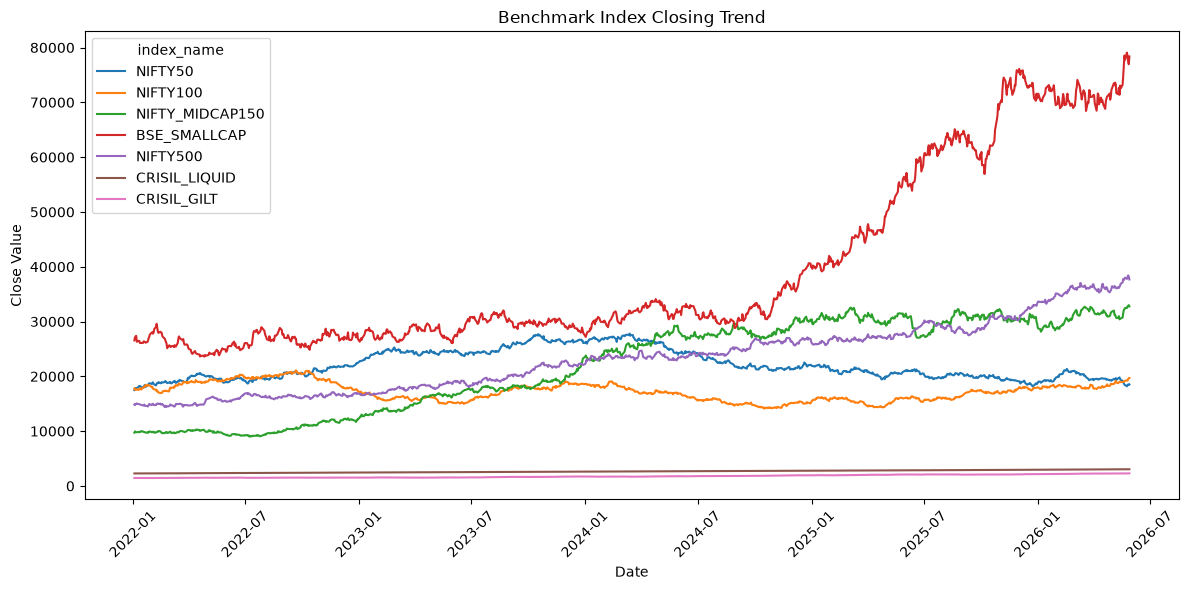

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("Benchmark Index Closing Trend")
plt.xlabel("Date")
plt.ylabel("Close Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/chart_14.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 14

**Insight:**
Benchmark indices showed an overall upward trend with periodic fluctuations, indicating positive long-term market performance.

**Reference:**
Chart 14 – Benchmark Index Closing Trend.

### 15TH CHART

# Chart 15: Transaction Amount Distribution by Gender

**Objective:**
To compare transaction amount distributions between male and female investors using a box plot.

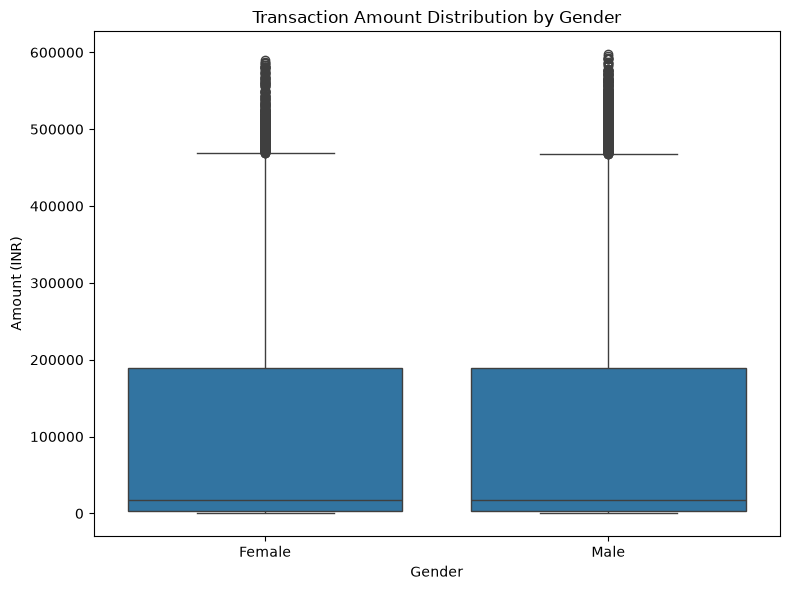

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/08_investor_transactions.csv")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="gender",
    y="amount_inr"
)

plt.title("Transaction Amount Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("../reports/chart_15.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 15

**Insight:**
Transaction amounts vary across genders, with a few high-value transactions appearing as outliers in both groups.

**Reference:**
Chart 15 – Transaction Amount Distribution by Gender.

### 16th chart

# Chart 16: Sector Allocation Donut Chart

**Objective:**
To visualize the percentage allocation of mutual fund investments across different sectors using a donut chart.

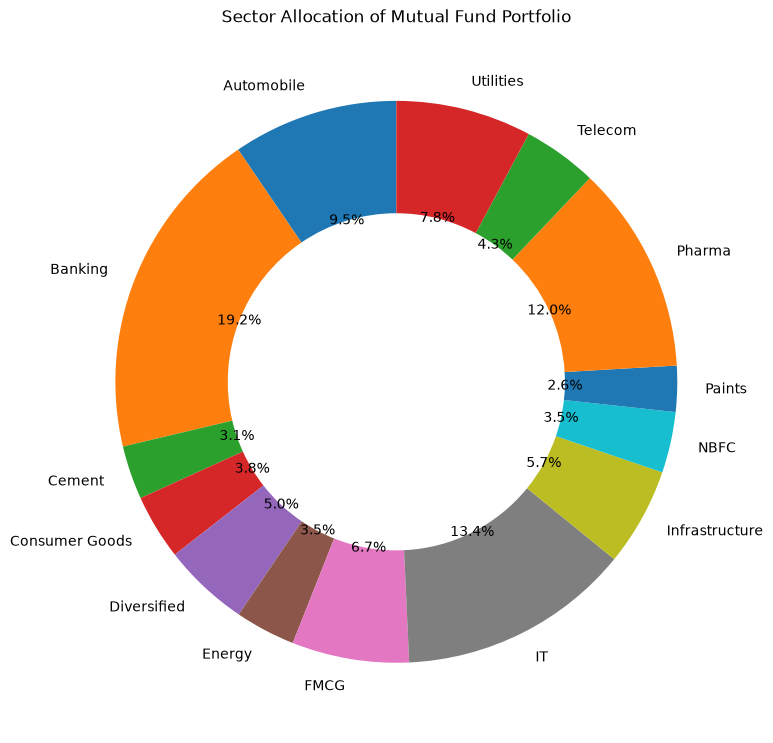

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Group by sector
sector_data = portfolio.groupby("sector")["weight_pct"].sum()

# Plot Donut Chart
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation of Mutual Fund Portfolio")

plt.tight_layout()
plt.savefig("../reports/chart_16.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 16

**Insight:**
Banking and IT sectors have the highest portfolio allocation, while Telecom, Paints, NBFC, and Cement contribute comparatively smaller allocations, indicating a diversified investment portfolio.

**Reference:**
Chart 16 – Sector Allocation Donut Chart.

In [1]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
